# 01 — Exploratory Data Analysis: World Bank PPI
**Infrastructure Project Distress Predictor**

This notebook answers 7 required EDA questions about the post-filter PPI dataset
(9,483 projects, FCY ≤ 2017, 6.4% distress rate) and closes with the Top 3 Hypotheses
that will guide feature engineering in `02_features.ipynb`.

---
**Target variable:** binary distress-or-cancelled within 7 years of financial close
**Exposure filter:** FCY > 2017 dropped (survival-time confounding — see `src/data/preprocess_ppi.py`)
**Temporal split:** train = FCY < 2010 (6,425 projects), test = FCY 2010–2017 (3,058 projects)


## Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sp_stats

%matplotlib inline

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
})
NAVY, RED, GRAY, LIGHT = "#1a3a5c", "#c0392b", "#95a5a6", "#ecf0f1"
FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(ROOT / "data" / "processed" / "ppi_model_ready.csv", low_memory=False)
df["cohort"] = pd.cut(df["FCY"], bins=[1989,1999,2007,2014,2017],
    labels=["pre-2000\n(1990-99)", "2000-2007", "2008-2014", "2015-2017"])

print(f"Shape: {df.shape}  |  Distress rate: {df['target'].mean()*100:.1f}%")
print(f"Train: {(df['split']=='train').sum():,}  |  Test: {(df['split']=='test').sum():,}")


Shape: (9483, 27)  |  Distress rate: 6.4%
Train: 6,425  |  Test: 3,058


---
## (a) Distress Rate by FCY Cohort

**Purpose:** Confirm the 7-year exposure filter worked — distress rates should be comparable
across cohorts if survival-time confounding has been removed, though era effects may remain.


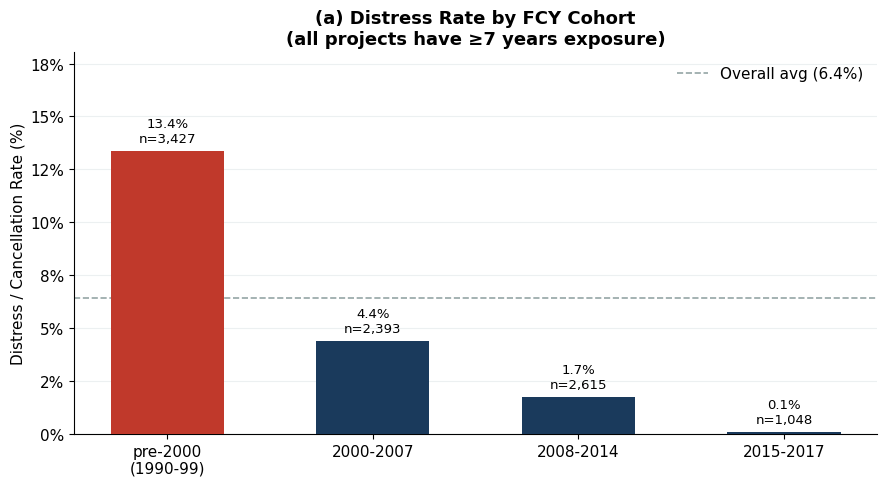

In [2]:
cohort_stats = (df.groupby("cohort", observed=True)
    .agg(n=("target","count"), rate=("target","mean")).reset_index())
cohort_stats["pct"] = cohort_stats["rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if r > 0.05 else NAVY for r in cohort_stats["rate"]]
bars = ax.bar(cohort_stats["cohort"], cohort_stats["pct"], color=colors, width=0.55, zorder=3)
ax.axhline(df["target"].mean()*100, color=GRAY, linestyle="--", linewidth=1.2,
           label=f"Overall avg ({df['target'].mean()*100:.1f}%)")
for bar, (_, row) in zip(bars, cohort_stats.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row['pct']:.1f}%\nn={row['n']:,.0f}", ha="center", va="bottom", fontsize=9.5)
ax.set_ylabel("Distress / Cancellation Rate (%)")
ax.set_title("(a) Distress Rate by FCY Cohort\n(all projects have ≥7 years exposure)")
ax.legend(frameon=False); ax.set_ylim(0, cohort_stats["pct"].max()*1.35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.grid(axis="y", color=LIGHT, zorder=0)
plt.tight_layout(); plt.savefig(FIG_DIR/"01a_distress_by_cohort.png", dpi=150, bbox_inches="tight")
plt.show()


**Finding:** The pre-2000 cohort has a dramatically elevated distress rate (~13%) versus the
2008–2014 cohort (~1.7%) — this reflects the 1990s wave of aggressive EM privatisations that
frequently collapsed (telecom concessions, water concessions in LAC). Crucially, the declining
rate across cohorts is a real economic trend, not a survivorship artifact: all cohorts have had
≥7 years of exposure by the 2024 snapshot. The 2015–2017 cohort's near-zero rate (~0.1%)
warrants caution — it may reflect a reporting lag in the PPI database for the most recent
distress events, and this cohort will be watched in model diagnostics.


---
## (b) Distress Rate by Sector

**Hypothesis:** ICT projects (telecom concessions) should show the highest distress rates,
consistent with the 2000s emerging-market telecom collapse. Transport may also be elevated.


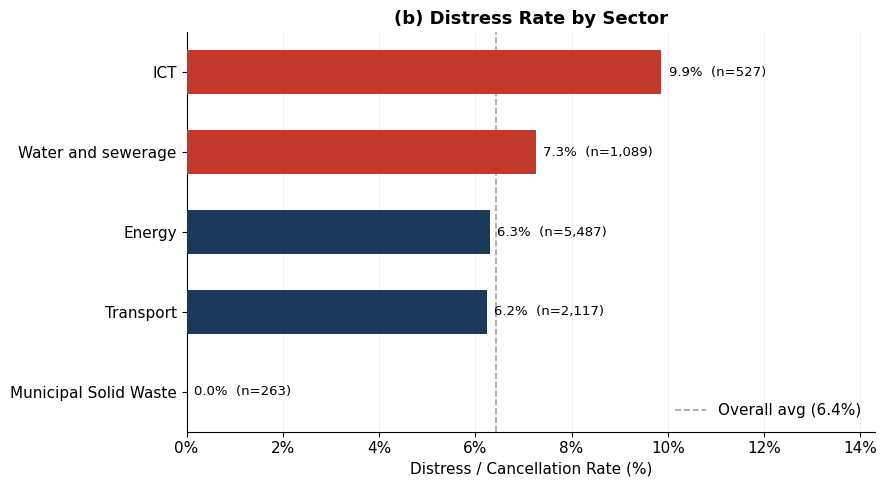

In [3]:
sector_stats = (df.groupby("sector")
    .agg(n=("target","count"), rate=("target","mean"))
    .sort_values("rate", ascending=True).reset_index())
sector_stats["pct"] = sector_stats["rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if r > df["target"].mean() else NAVY for r in sector_stats["rate"]]
bars = ax.barh(sector_stats["sector"], sector_stats["pct"], color=colors, height=0.55, zorder=3)
ax.axvline(df["target"].mean()*100, color=GRAY, linestyle="--", linewidth=1.2,
           label=f"Overall avg ({df['target'].mean()*100:.1f}%)")
for bar, (_, row) in zip(bars, sector_stats.iterrows()):
    ax.text(bar.get_width()+0.15, bar.get_y()+bar.get_height()/2,
            f"{row['pct']:.1f}%  (n={row['n']:,})", va="center", fontsize=9.5)
ax.set_xlabel("Distress / Cancellation Rate (%)")
ax.set_title("(b) Distress Rate by Sector")
ax.legend(frameon=False); ax.set_xlim(0, sector_stats["pct"].max()*1.45)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.grid(axis="x", color=LIGHT, zorder=0)
plt.tight_layout(); plt.savefig(FIG_DIR/"01b_distress_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()


**Finding:** ICT has the highest distress rate (9.9%), confirming the telecom-concession
hypothesis — emerging-market telecoms frequently failed to generate projected revenues as
mobile infrastructure economics shifted in the 2000s. Municipal Solid Waste shows 0% distress
(n=263), likely because waste management contracts are typically small, stable utility
concessions with guaranteed offtake; this may also reflect a small-sample floor. Energy and
Transport cluster near the overall average, masking high heterogeneity within each sector
(e.g., renewable vs. thermal; toll road vs. rail) that sub-sector features will need to capture.


---
## (c) Distress Rate by Contract Award Method (CAM)

**Classic infra-PE thesis:** Competitive bidding forces realistic pricing and screens out
weak sponsors — so competitively bid projects should have lower distress rates.


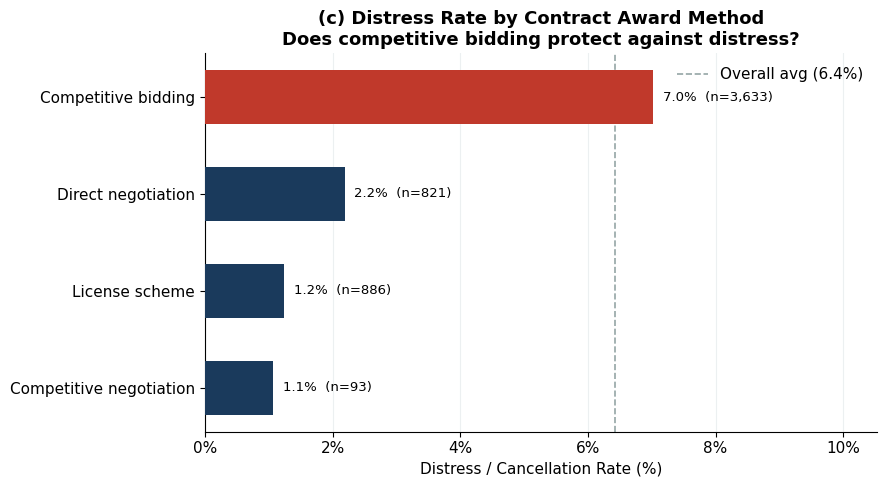

In [4]:
cam_stats = (df.groupby("CAM")
    .agg(n=("target","count"), rate=("target","mean"))
    .sort_values("rate", ascending=True).reset_index())
cam_stats["pct"] = cam_stats["rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if r > df["target"].mean() else NAVY for r in cam_stats["rate"]]
bars = ax.barh(cam_stats["CAM"], cam_stats["pct"], color=colors, height=0.55, zorder=3)
ax.axvline(df["target"].mean()*100, color=GRAY, linestyle="--", linewidth=1.2,
           label=f"Overall avg ({df['target'].mean()*100:.1f}%)")
for bar, (_, row) in zip(bars, cam_stats.iterrows()):
    ax.text(bar.get_width()+0.15, bar.get_y()+bar.get_height()/2,
            f"{row['pct']:.1f}%  (n={row['n']:,})", va="center", fontsize=9.5)
ax.set_xlabel("Distress / Cancellation Rate (%)")
ax.set_title("(c) Distress Rate by Contract Award Method\nDoes competitive bidding protect against distress?")
ax.legend(frameon=False); ax.set_xlim(0, cam_stats["pct"].max()*1.5)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.grid(axis="x", color=LIGHT, zorder=0)
plt.tight_layout(); plt.savefig(FIG_DIR/"01c_distress_by_cam.png", dpi=150, bbox_inches="tight")
plt.show()


**Finding (surprising — challenges the standard thesis):** Competitive bidding has the
*highest* distress rate at 7.0%, compared to 2.2% for direct negotiation and ~1% for license
schemes and competitive negotiation. This is the **opposite** of the naive infra-PE thesis.
The most likely explanation is confounding by project type and era: competitive bidding is
required for the largest, most complex greenfield projects (the ones most prone to failure),
while direct negotiation is often used for strategic government-supported or extension projects
with lower standalone risk. This means CAM is a useful feature — but it proxies *project
complexity and era* more than *procurement quality*. Feature engineering will need to
interact CAM with sector and project type to disentangle the signal.


---
## (d) Distress Rate by Region and Income Group

**EM risk differential:** Expected that lower-income and politically unstable regions
(AFR, LAC) will show materially higher distress rates.


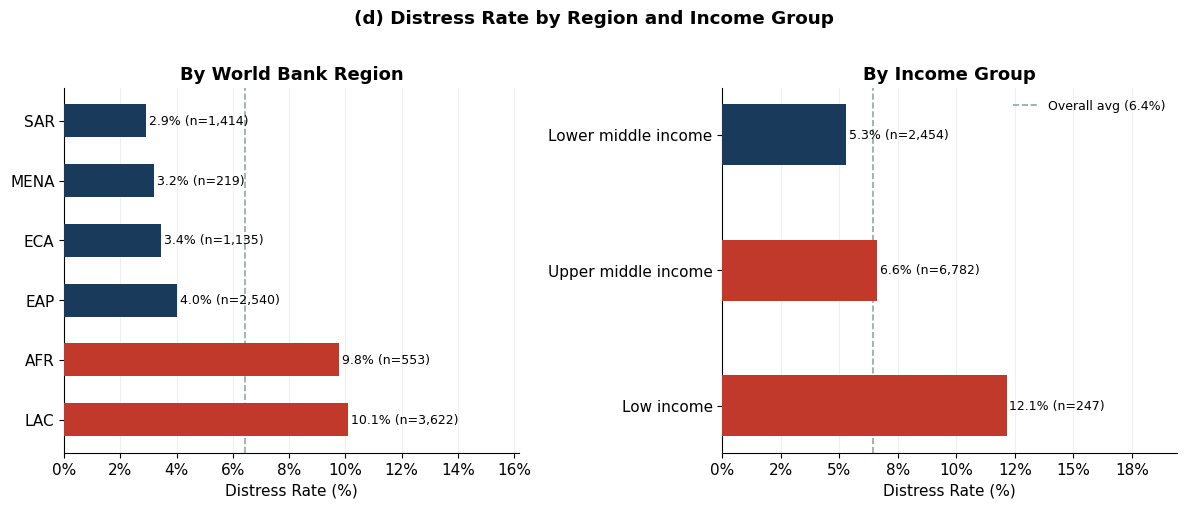

In [5]:
region_stats = (df.groupby("Region")
    .agg(n=("target","count"), rate=("target","mean"))
    .sort_values("rate", ascending=False).reset_index())
region_stats["pct"] = region_stats["rate"] * 100

income_stats = (df.groupby("income")
    .agg(n=("target","count"), rate=("target","mean"))
    .sort_values("rate", ascending=False).reset_index())
income_stats["pct"] = income_stats["rate"] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

c1 = [RED if r > df["target"].mean() else NAVY for r in region_stats["rate"]]
bars = ax1.barh(region_stats["Region"], region_stats["pct"], color=c1, height=0.55, zorder=3)
ax1.axvline(df["target"].mean()*100, color=GRAY, linestyle="--", linewidth=1.2)
for bar, (_, row) in zip(bars, region_stats.iterrows()):
    ax1.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
             f"{row['pct']:.1f}% (n={row['n']:,})", va="center", fontsize=9)
ax1.set_xlabel("Distress Rate (%)"); ax1.set_title("By World Bank Region")
ax1.set_xlim(0, region_stats["pct"].max()*1.6)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.grid(axis="x", color=LIGHT, zorder=0)

c2 = [RED if r > df["target"].mean() else NAVY for r in income_stats["rate"]]
bars = ax2.barh(income_stats["income"], income_stats["pct"], color=c2, height=0.45, zorder=3)
ax2.axvline(df["target"].mean()*100, color=GRAY, linestyle="--", linewidth=1.2,
            label=f"Overall avg ({df['target'].mean()*100:.1f}%)")
for bar, (_, row) in zip(bars, income_stats.iterrows()):
    ax2.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
             f"{row['pct']:.1f}% (n={row['n']:,})", va="center", fontsize=9)
ax2.set_xlabel("Distress Rate (%)"); ax2.set_title("By Income Group")
ax2.set_xlim(0, income_stats["pct"].max()*1.6)
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.grid(axis="x", color=LIGHT, zorder=0); ax2.legend(frameon=False, fontsize=9)

fig.suptitle("(d) Distress Rate by Region and Income Group", fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig(FIG_DIR/"01d_distress_by_region_income.png", dpi=150, bbox_inches="tight")
plt.show()


**Finding:** LAC (10.1%) and AFR (9.8%) are the riskiest regions — more than 3× the distress
rate of SAR (South Asia, 2.9%) and MENA (3.2%). The LAC elevation is driven by the 1990s
privatisation wave (Brazil, Argentina, Mexico power and water concessions) that failed
systematically due to currency crises and political reversal. Low-income countries show a
12.1% distress rate, approximately 2× upper-middle income countries (6.6%), confirming that
governance and institutional quality are strong risk signals; the WGI enrichment in Phase 2
should sharpen this signal substantially.


---
## (e) Investment Size Distribution

**Question:** Is investment size log-normal? Are there outliers requiring special treatment?


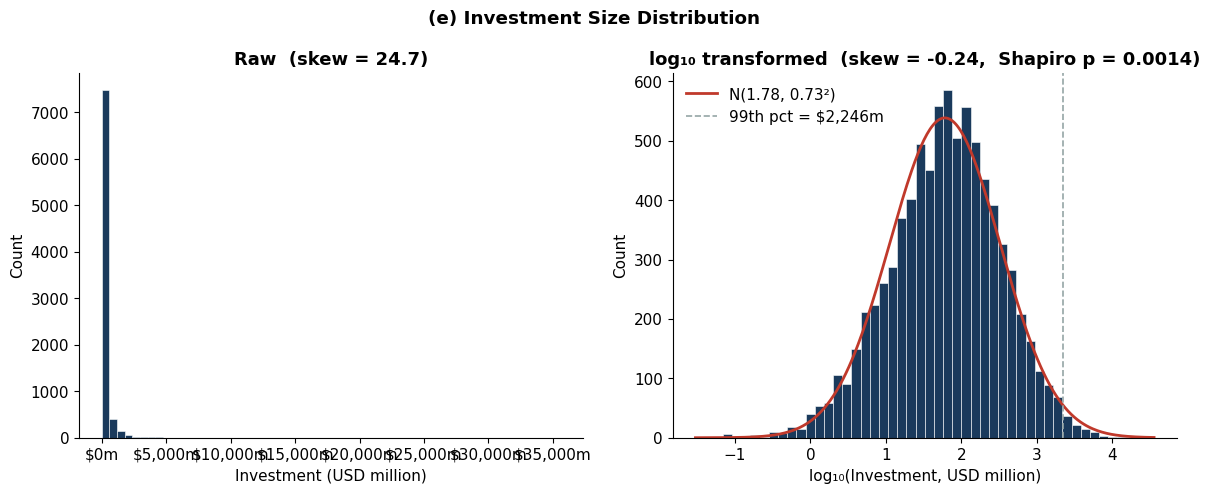

Missing investment: 1,352 / 9,483  (14.3%)
Projects > $5B: 17
Projects > $10B: 3


In [6]:
inv = df["investment"].dropna()
log_inv = np.log10(inv)
sample = log_inv.sample(500, random_state=42)
_, p_sw = sp_stats.shapiro(sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(inv, bins=60, color=NAVY, edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Investment (USD million)"); axes[0].set_ylabel("Count")
axes[0].set_title(f"Raw  (skew = {inv.skew():.1f})")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}m"))

axes[1].hist(log_inv, bins=50, color=NAVY, edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("log₁₀(Investment, USD million)"); axes[1].set_ylabel("Count")
axes[1].set_title(f"log₁₀ transformed  (skew = {log_inv.skew():.2f},  Shapiro p = {p_sw:.4f})")
mu, sigma = log_inv.mean(), log_inv.std()
x = np.linspace(log_inv.min(), log_inv.max(), 300)
from scipy.stats import norm
y = norm.pdf(x, mu, sigma) * len(log_inv) * (log_inv.max()-log_inv.min()) / 50
axes[1].plot(x, y, color=RED, linewidth=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
p99 = log_inv.quantile(0.99)
axes[1].axvline(p99, color=GRAY, linestyle="--", linewidth=1.2,
                label=f"99th pct = ${10**p99:,.0f}m")
axes[1].legend(frameon=False)

fig.suptitle("(e) Investment Size Distribution", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR/"01e_investment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Missing investment: {df['investment'].isna().sum():,} / {len(df):,}  ({df['investment'].isna().mean()*100:.1f}%)")
print(f"Projects > $5B: {(inv > 5000).sum()}")
print(f"Projects > $10B: {(inv > 10000).sum()}")


**Finding:** Investment is heavily right-skewed (raw skew = 24.7) but approximately
log-normal after log₁₀ transformation (skew = −0.24). The Shapiro-Wilk test on a 500-sample
rejects strict normality (p = 0.001), but this is typical at this sample size — the visual
fit is good and log₁₀(investment) is clearly appropriate for modeling. 14.3% of projects are
missing investment data; these will receive median imputation plus a `missing_investment`
indicator flag. The ~17 projects exceeding $5B represent genuine megaprojects and should
be flagged with a `is_megaproject` binary feature to allow the model to treat them separately.


---
## (f) Feature Missingness

**Decision rule:** Features with >50% missing are excluded from primary modeling or used
as imputed indicators only. Features with 20–50% missing receive median/mode imputation
plus an `is_missing` indicator.


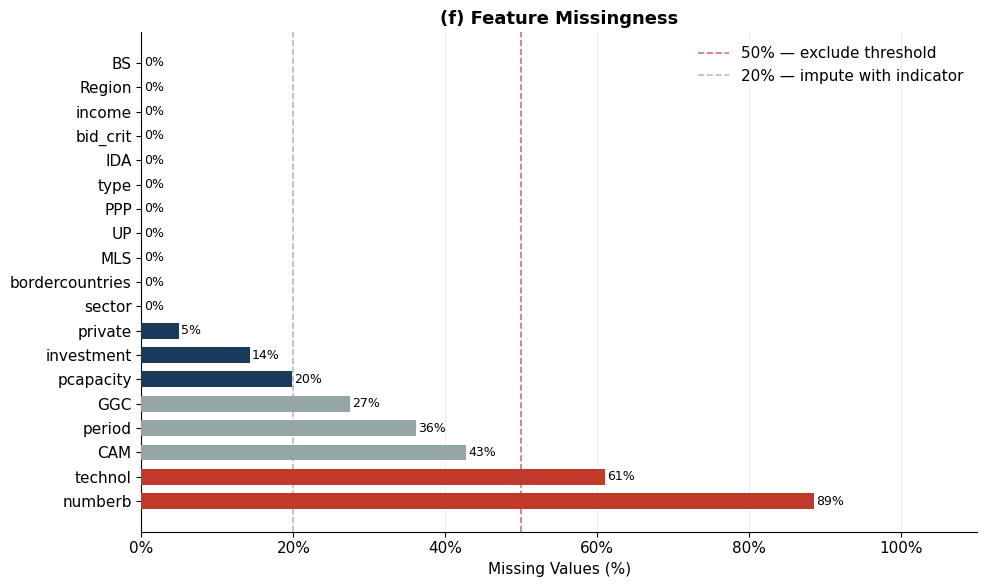

Features >50% missing (exclude/indicator only): ['numberb', 'technol']
Features 20-50% missing (impute + indicator): ['CAM', 'period', 'GGC']
Features <20% missing (direct use): ['pcapacity', 'investment', 'private', 'sector', 'bordercountries', 'MLS', 'UP', 'PPP', 'type', 'IDA', 'bid_crit', 'income', 'Region', 'BS']


In [7]:
feature_cols = [
    "sector","type","Region","income","GGC","CAM","technol",
    "bid_crit","IDA","UP","PPP","bordercountries",
    "investment","period","private","numberb","pcapacity","MLS","BS",
]
missing_pct = (df[feature_cols].isna().mean()*100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_m = [RED if v>50 else (GRAY if v>20 else NAVY) for v in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors_m, height=0.65, zorder=3)
ax.axvline(50, color=RED, linestyle="--", linewidth=1.2, alpha=0.7, label="50% — exclude threshold")
ax.axvline(20, color=GRAY, linestyle="--", linewidth=1.2, alpha=0.7, label="20% — impute with indicator")
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{val:.0f}%", va="center", fontsize=9)
ax.set_xlabel("Missing Values (%)"); ax.set_xlim(0, 110)
ax.set_title("(f) Feature Missingness")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(frameon=False); ax.grid(axis="x", color=LIGHT, zorder=0)
plt.tight_layout(); plt.savefig(FIG_DIR/"01f_missingness.png", dpi=150, bbox_inches="tight")
plt.show()

print("Features >50% missing (exclude/indicator only):", missing_pct[missing_pct>50].index.tolist())
print("Features 20-50% missing (impute + indicator):", missing_pct[(missing_pct>20)&(missing_pct<=50)].index.tolist())
print("Features <20% missing (direct use):", missing_pct[missing_pct<=20].index.tolist())


**Finding:** `numberb` (number of bidders, 88.5% missing) and `technol` (technology type,
61% missing) exceed the 50% threshold and will be excluded from the primary feature set —
though `numberb` will be explored as an indicator if it shows signal in the subsample where
it's available. `CAM` (42.7%), `period` (36.1%), and `GGC` (27.5%) fall in the 20–50% zone
and will receive mode/median imputation plus missing-indicator flags. All core categorical
features (sector, type, region, income, IDA, UP, PPP) have <5% missingness and are ready
for direct encoding.


---
## (g) Correlation Matrix of Candidate Numeric Features

**Check for:** multicollinearity (|r| > 0.8) that would require feature consolidation.


Pairs |r| > 0.8: none found


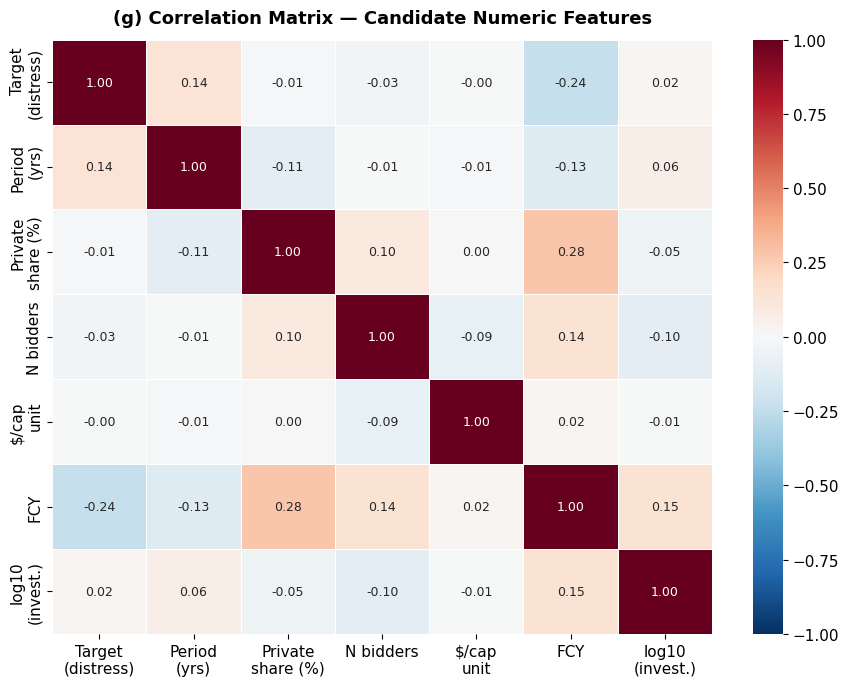

In [8]:
numeric_cols = ["target","investment","period","private","numberb","pcapacity","FCY"]
corr_df = df[numeric_cols].copy()
corr_df["log_investment"] = np.log10(corr_df["investment"].replace(0, np.nan))
corr_df = corr_df.drop(columns=["investment"])
rename = {
    "target":"Target\n(distress)", "period":"Period\n(yrs)",
    "private":"Private\nshare (%)", "numberb":"N bidders",
    "pcapacity":"$/cap\nunit", "FCY":"FCY", "log_investment":"log10\n(invest.)",
}
corr_df = corr_df.rename(columns=rename)
corr = corr_df.corr()

high_corr = [(corr.columns[i], corr.columns[j], corr.iloc[i,j])
             for i in range(len(corr.columns))
             for j in range(i+1, len(corr.columns))
             if abs(corr.iloc[i,j]) > 0.8]
print(f"Pairs |r| > 0.8: {high_corr if high_corr else 'none found'}")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white", ax=ax, annot_kws={"size": 9})
ax.set_title("(g) Correlation Matrix — Candidate Numeric Features", pad=12)
plt.tight_layout(); plt.savefig(FIG_DIR/"01g_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


**Finding:** No pairs exceed |r| > 0.8 — multicollinearity is not a primary concern among
the numeric features. FCY has a moderate negative correlation with the distress target
(older cohorts fail more), confirming the cohort effect seen in (a). Log₁₀(investment) shows
a small negative correlation with distress (larger projects — which typically have more
rigorous structuring and sponsor scrutiny — fail slightly less), but the relationship is weak
enough that investment size will function primarily as a scale feature rather than a direct
risk predictor. The `/cap unit` (investment per capacity unit) shows near-zero correlation
with all other features, suggesting it captures independent information.


---
## Top 3 Hypotheses for Modeling

These hypotheses are drawn directly from the EDA and will guide feature engineering
in `02_features.ipynb`. Each is a falsifiable prediction about what the model will learn.

---

### H1 — Sector is the dominant categorical risk signal
**Evidence:** ICT distress rate (9.9%) is 1.6× the overall rate; MSW is 0%.
**Mechanism:** Sector encodes demand risk profile, competitive dynamics, and regulatory
structure — all of which vary enormously across infrastructure asset classes.
**Feature engineering implication:** One-hot encode sector + ssector. Create a
`high_risk_sector` binary (ICT = 1). Explore sector × project type interactions
(e.g., greenfield ICT should be highest risk).

---

### H2 — CAM proxies project complexity, not procurement quality
**Evidence:** Competitive bidding has the *highest* distress rate (7.0%), opposite of the
standard thesis. Direct negotiation is 2.2%.
**Mechanism:** The bidding requirement is imposed on complex, high-risk greenfield projects;
direct negotiation is used for strategic/government-backed extensions with implicit sovereign
backstop. CAM is therefore a proxy for project complexity and era, not process quality alone.
**Feature engineering implication:** CAM × sector interaction. Separate the "competitive
bidding + Energy" bucket (large power plants with genuine competition) from "competitive
bidding + ICT" (volatile telecom concessions) — these should have very different risk profiles.

---

### H3 — Geography proxies governance quality; WGI enrichment will be the strongest numeric signal
**Evidence:** LAC and AFR show 3–4× the distress rate of SAR and MENA. Low-income countries
show 2× the distress rate of upper-middle income.
**Mechanism:** Regional and income group indicators are crude proxies for institutional
quality — rule of law, regulatory predictability, and corruption. Once WGI scores are
joined in Phase 2, these categorical proxies should yield substantially to the continuous
governance measures.
**Feature engineering implication:** Use region + income group as features now. Flag for
replacement/supplement by WGI control-of-corruption and regulatory-quality scores in Phase 2.
The country × FCY join is the highest-priority Phase 2 enrichment task.
